## Term Paper - Winter Semester 25/26 Submission

#### **Research Topic: Is Attention All You Need in Low-Resource Settings? An empirical study of self attention integrated with BiLSTM vs Transformers for a low resource language; Swahili.**

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
holdout_train = pd.read_csv("Swahili_News_Train.csv")
holdout_test = pd.read_csv("Swahili_News_Test.csv")

print(f"Validate train column names: {holdout_train.columns},\nValidate test column names: {holdout_test.columns}")

Validate train column names: Index(['id', 'content', 'category'], dtype='object'),
Validate test column names: Index(['swahili_id', 'content'], dtype='object')


In [3]:
swahili_news = pd.read_csv("SwahiliNewsClassificationDataset.csv")
swahili_news.head()

,id,content,category
0,SW4670,"Bodi ya Utalii Tanzania (TTB) imesema, itafan...",uchumi
1,SW30826,"PENDO FUNDISHA-MBEYA RAIS Dk. John Magufuri, ...",kitaifa
2,SW29725,Mwandishi Wetu -Singida BENKI ya NMB imetoa ms...,uchumi
3,SW20901,"TIMU ya taifa ya Tanzania, Serengeti Boys jan...",michezo
4,SW12560,Na AGATHA CHARLES – DAR ES SALAAM ALIYEKUWA K...,kitaifa


In [ ]:
print(f"Training set has {swahili_news.shape[0]} rows while validation/developer set has {holdout_train.shape[0]} rows.")

Training set has 23268 rows while validation/developer set has 5151 rows.


In [ ]:
print(f"Categories in training but missing in validation: {set(swahili_news["category"].str.lower().unique()) - set(holdout_train["category"].str.lower().unique())}")

Categories in training but missing in validation: {'uchumi', 'afya'}


In [ ]:
print(f"Categories in validation but missing in training: {set(holdout_train["category"].str.lower().unique()) - set(swahili_news["category"].str.lower().unique())}")

Categories in validation but missing in training: {'biashara'}


In [ ]:
print(f"Categories in validation but missing in training: {set(holdout_train["category"].unique()) - set(swahili_news["category"].unique())}")

Categories in validation but missing in training: {'Burudani', 'Kitaifa', 'Kimataifa', 'Biashara'}


In [ ]:
print(f"Categories is training data: {swahili_news["category"].str.lower().unique()}.\nCategories in validation set: {holdout_train["category"].str.lower().unique()}")

Categories is training data: ['uchumi' 'kitaifa' 'michezo' 'kimataifa' 'burudani' 'afya'].
Categories in validation set: ['kitaifa' 'biashara' 'michezo' 'kimataifa' 'burudani']


In [ ]:
set(holdout_train["category"].str.lower().unique()) & set(swahili_news["category"].str.lower().unique())

{'burudani', 'kimataifa', 'kitaifa', 'michezo'}

In [10]:
swahili_news["category"].value_counts()

category
kitaifa      10242
michezo       6004
burudani      2229
uchumi        2028
kimataifa     1906
afya           859
Name: count, dtype: int64

In [ ]:
holdout_train["category"].value_counts()

category
Kitaifa      2000
michezo      1720
Biashara     1360
Kimataifa      54
Burudani       17
Name: count, dtype: int64

Training set has 23268 rows while validation/developer set has 5151 rows.


<Axes: xlabel='category', ylabel='count'>

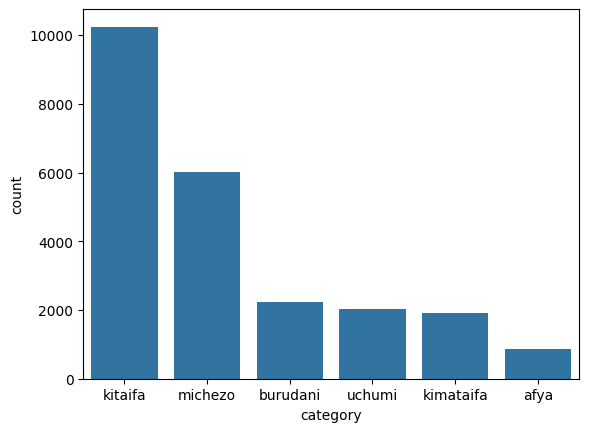

In [19]:
sns.countplot(x="category", data=swahili_news, order=swahili_news["category"].value_counts().index)

<Axes: xlabel='category', ylabel='count'>

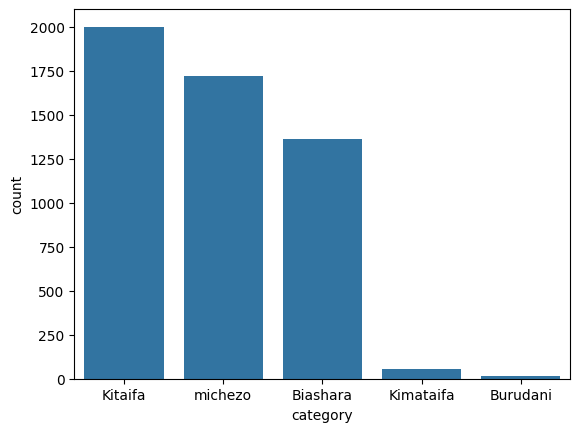

In [ ]:
sns.countplot(x="category", data=holdout_train, order=holdout_train["category"].value_counts().index)